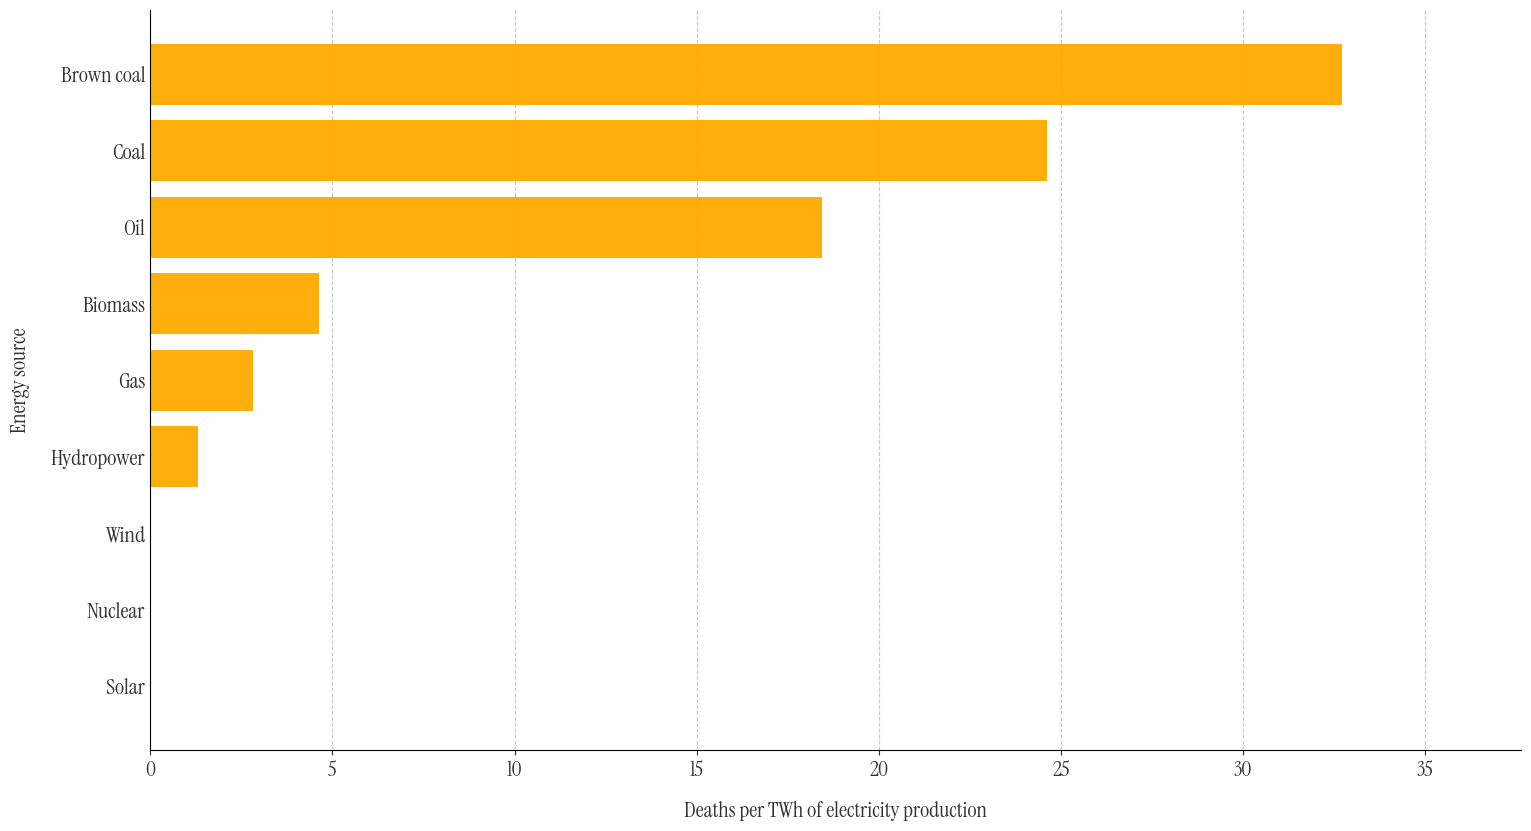

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from dotenv import load_dotenv
import os

# -----------------------------
# 1. Font setup
# -----------------------------
FONT_PATH = "./font.ttf"
fm.fontManager.addfont(FONT_PATH)
font_prop = fm.FontProperties(fname=FONT_PATH)
FONT_NAME = font_prop.get_name()

# -----------------------------
# 2. Load data
# -----------------------------
df = pd.read_csv("./data/death-rates-from-energy-production-per-twh.csv")

df = (
    df.rename(columns={"Deaths per TWh of electricity production": "Deaths_per_TWh"})
      .sort_values("Deaths_per_TWh", ascending=True)
)

# -----------------------------
# 3. Colors
# -----------------------------
load_dotenv("colors.env", override=True)

BAR_COLOR = os.getenv("NUCLEAR")
BLACK = os.getenv("BLACK")
WHITE = os.getenv("WHITE")

# -----------------------------
# 4. Global style (IDENTICAL)
# -----------------------------
plt.rcParams.update({
    "font.family": FONT_NAME,
    "font.size": 16,

    "text.color": BLACK,
    "axes.labelcolor": BLACK,
    "xtick.color": BLACK,
    "ytick.color": BLACK,

    "figure.facecolor": "none",
    "axes.facecolor": "none",

    "axes.spines.top": False,
    "axes.spines.right": False,

    "grid.color": BLACK,
    "grid.linestyle": "--",
    "grid.alpha": 0.25,
})

# -----------------------------
# 5. Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(16, 9))

bars = ax.barh(
    df["Entity"],
    df["Deaths_per_TWh"],
    color=BAR_COLOR,
    alpha=0.95
)

# -----------------------------
# 6. Axes & labels (MATCHED)
# -----------------------------
ax.set_xlabel(
    "Deaths per TWh of electricity production",
    fontsize=16,
    labelpad=15
)

ax.set_ylabel(
    "Energy source",
    fontsize=16,
    labelpad=15
)

ax.tick_params(axis="both", labelsize=16)
ax.tick_params(axis="y", length=0)

ax.grid(True, axis="x")
ax.set_axisbelow(True)

# -----------------------------
# 7. Value labels (MATCHED)
# -----------------------------
max_val = df["Deaths_per_TWh"].max()

for bar in bars:
    ax.text(
        bar.get_width() + max_val * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.3g}",
        va="center",
        ha="left",
        fontsize=14,
        fontweight="bold",
        color=WHITE
    )

ax.set_xlim(0, max_val * 1.15)

# -----------------------------
# 8. Export (MATCHED)
# -----------------------------
plt.tight_layout(pad=2)
plt.savefig(
    "./death_rates_energy_production_BLACK.svg",
    format="svg",
    bbox_inches="tight",
    # transparent=True
)
plt.show()
